In [2]:
import pandas as pd
file_path = "Zepto_blinkit.xlsx"
df = pd.read_excel(file_path, sheet_name="Table2")
print(df.shape)

(1616, 10)


In [4]:
print(df.dtypes)

Brand                        object
Date                 datetime64[ns]
Product                      object
Category                     object
City                         object
Price                         int64
Quantity                      int64
DeliveryTime(min)             int64
PaymentMode                  object
Rating                      float64
dtype: object


In [6]:
print(df.describe())

                                Date        Price     Quantity  \
count                           1616  1616.000000  1616.000000   
mean   2024-08-16 04:21:58.811881216   137.820545     2.974629   
min              2024-04-01 00:00:00    30.000000     1.000000   
25%              2024-05-28 00:00:00    78.000000     2.000000   
50%              2024-07-14 00:00:00   141.000000     3.000000   
75%              2024-11-02 06:00:00   194.000000     4.000000   
max              2025-03-31 00:00:00   250.000000     5.000000   
std                              NaN    64.503706     1.406742   

       DeliveryTime(min)       Rating  
count        1616.000000  1321.000000  
mean           15.488243     2.973505  
min             7.000000     1.000000  
25%            12.000000     2.000000  
50%            15.000000     3.000000  
75%            19.000000     4.000000  
max            25.000000     5.000000  
std             4.581277     1.406714  


DATA CLEANING

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
print("\nMissing values before:\n", df.isnull().sum())


Missing values before:
 Brand                  0
Date                   0
Product                0
Category               0
City                   0
Price                  0
Quantity               0
DeliveryTime(min)      0
PaymentMode            0
Rating               295
dtype: int64


In [9]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

Standardize categorical columns

In [10]:
cat_cols = ["Brand", "Product", "Category", "City", "PaymentMode"]

for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

FEATURE ENGINEERING

In [14]:
df["TotalAmount"] = df["Price"] * df["Quantity"]

In [16]:
def speed_group(t):
    if t < 15:
        return "Fast"
    elif t <= 20:
        return "Medium"
    else:
        return "Slow"
df["DeliverySpeed"] = df["DeliveryTime(min)"].apply(speed_group)

In [17]:
df["OrderMonth"] = df["Date"].dt.month_name()

In [18]:
df["OrderWeekday"] = df["Date"].dt.day_name()

In [19]:
df["OrderDay"] = df["Date"].dt.day

In [20]:
df["IsWeekend"] = df["OrderWeekday"].isin(["Saturday", "Sunday"])

In [ ]:
def rate_group(r):
    if r <= 2:
        return "Low"
    elif r == 3:
        return "Medium"
    else:
        return "High"

df["RatingCategory"] = df["Rating"].apply(rate_group)

In [23]:
print(df.head())
print("\nNew columns:", df.columns)

     Brand       Date   Product Category       City  Price  Quantity  \
0  Blinkit 2024-04-01  Biscuits   Bakery  Hyderabad    127         3   
1  Blinkit 2024-04-02      Atta   Grains  Bangalore    142         3   
2    Zepto 2024-04-03    Paneer    Dairy    Chennai    170         5   
3  Blinkit 2024-04-04      Milk    Dairy     Mumbai    249         3   
4    Zepto 2024-04-05  Biscuits   Bakery      Delhi    161         4   

   DeliveryTime(min) PaymentMode  Rating  TotalAmount DeliverySpeed  \
0                 18        Card     3.0          381        Medium   
1                 12         Upi     1.0          426          Fast   
2                  9         Upi     3.0          850          Fast   
3                 16         Upi     2.0          747        Medium   
4                 12         Upi     2.0          644          Fast   

  OrderMonth OrderWeekday  OrderDay  IsWeekend RatingCategory  
0      April       Monday         1      False         Medium  
1      April

UNIVARIATE ANALYSIS

Brand
Blinkit    859
Zepto      757
Name: count, dtype: int64


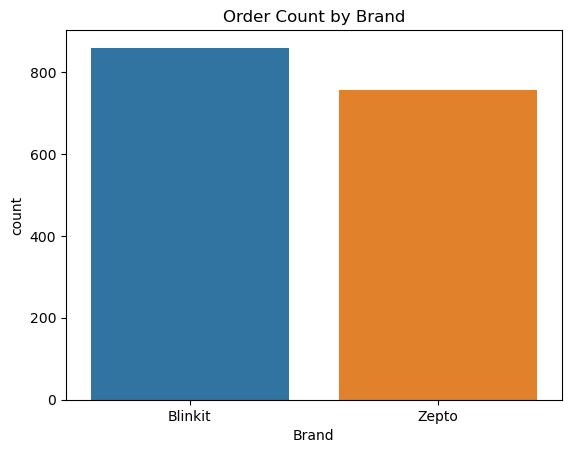

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df['Brand'].value_counts())
sns.countplot(x=df['Brand'])
plt.title("Order Count by Brand")
plt.show()

City
Mumbai       347
Chennai      325
Hyderabad    319
Bangalore    319
Delhi        306
Name: count, dtype: int64


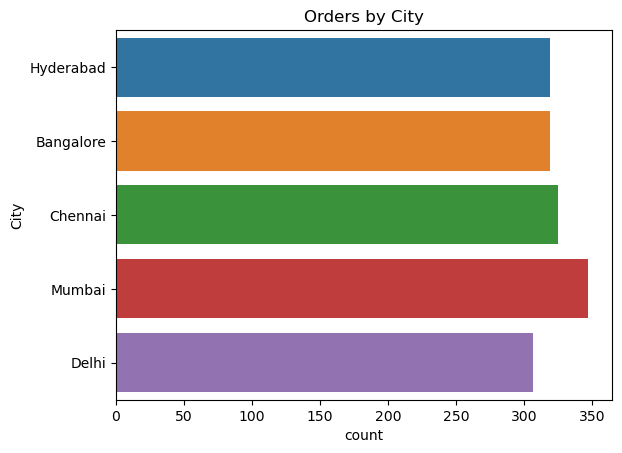

In [27]:
print(df['City'].value_counts())
sns.countplot(y=df['City'])
plt.title("Orders by City")
plt.show()

Category
Dairy        464
Bakery       291
Grains       284
Beverages    270
Poultry      165
Snacks       142
Name: count, dtype: int64


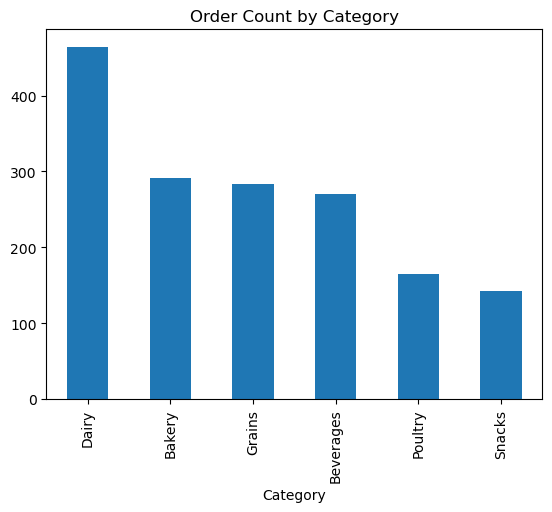

In [28]:
print(df['Category'].value_counts())
df['Category'].value_counts().plot(kind='bar')
plt.title("Order Count by Category")
plt.show()

PaymentMode
Upi     562
Cod     534
Card    520
Name: count, dtype: int64


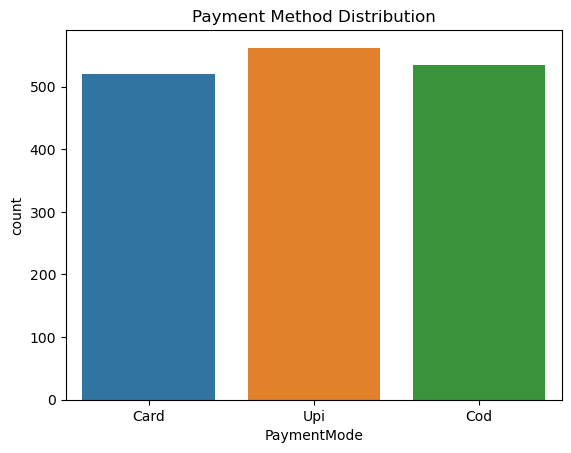

In [29]:
print(df['PaymentMode'].value_counts())
sns.countplot(x=df['PaymentMode'])
plt.title("Payment Method Distribution")
plt.show()

c:\Users\palak\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


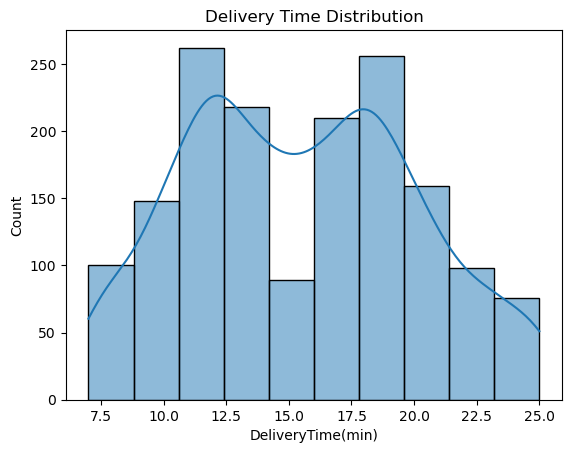

In [30]:
sns.histplot(df['DeliveryTime(min)'], bins=10, kde=True)
plt.title("Delivery Time Distribution")
plt.show()

c:\Users\palak\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


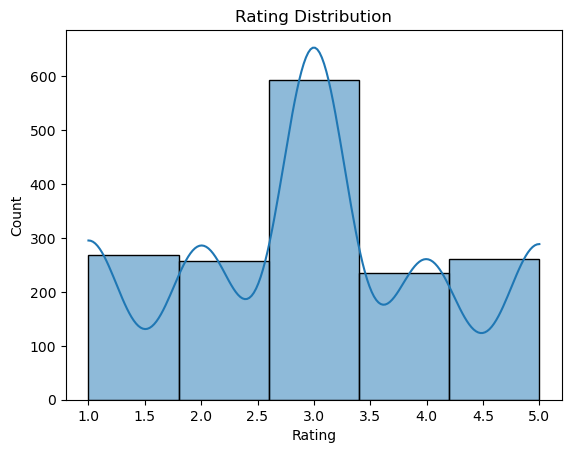

In [31]:
sns.histplot(df['Rating'], bins=5, kde=True)
plt.title("Rating Distribution")
plt.show()